In [27]:
# making somewhat cleaned-up versions of figures for Figure 3 in the main text + related Supplementary Figures
# note that the figures produced by this code were subsequently edited in Adobe Illustrator
# (arranged into main and supplementary figures & annotated; nothing beyond that was changed)

In [37]:
import os
import re
import importlib
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import cm
import matplotlib.font_manager

import utils # ./utils.py
importlib.reload(utils)

<module 'utils' from '/Users/alyulina/Research/metastatic-phenotypes/code/utils.py'>

In [3]:
# pre-processed data:
# excluded samples: SK1_8 (very low coverage), SK1_11 (duplicate of SK1_10), LS01_17 (no spike-in detected), LS01_32 (no reads)
metadata = pd.read_csv('/Users/alyulina/Research/metastatic-phenotypes/data/metadata.csv', index_col='sample id') # all sequencing samples
read_counts_by_cell_line = pd.read_csv('/Users/alyulina/Research/metastatic-phenotypes/data/cell-line_read_counts.csv', index_col='clID')
cell_counts_by_cell_line = pd.read_csv('/Users/alyulina/Research/metastatic-phenotypes/data/cell-line_cell_counts.csv', index_col='clID')

clIDs = utils.clIDs
clID__label = utils.clID__label
clID__color = utils.clID__color_in_vivo 
clID_replicates__linestyle = utils.clID_replicates__linestyle

# where to find data:
path_to_reads = '/Users/alyulina/Research/metastatic-phenotypes/data/bc_counts/'

# where to save plots:
path_to_save_figs = '/Users/alyulina/Research/metastatic-phenotypes/figures/fig3/figs/'


In [4]:
# note that the figures might change slightly each time you run this code, 
# so make sure to update annotations accordingly

### Immune rejection plots

In [5]:
# making a list of 3w F1 iv lung samples from exp. one
what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [6]:
# making a list of 3w Rag1 iv lung samples from exp. one
what = ['1', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_wo_immune_system = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['injection method'] == what[3]) & 
                                   (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [7]:
(
    clID__in_vivo_exp, 
    clID__in_vivo_exp_rel, 
    clID__in_vivo_exp_avg_relative_to_mean, 
    clID__in_vivo_exp_err, 
    clIDs_sorted
) = utils.bootstrap_relative_burden(
    samples, 
    read_counts=read_counts_by_cell_line, 
    cell_counts=cell_counts_by_cell_line, 
    metadata=metadata
)
                                                                                                                                                                                                                                                                                                                                                                                                            
(
    clID__in_vivo_exp_wo_immune_system, 
    clID__in_vivo_exp_wo_immune_system_rel, 
    clID__in_vivo_exp_avg_wo_immune_system_relative_to_mean, 
    clID__in_vivo_exp_wo_immune_system_err, 
    clIDs_sorted_wo_immune_system 
) = utils.bootstrap_relative_burden(
    samples_wo_immune_system, 
    read_counts=read_counts_by_cell_line, 
    cell_counts=cell_counts_by_cell_line, 
    metadata=metadata
)

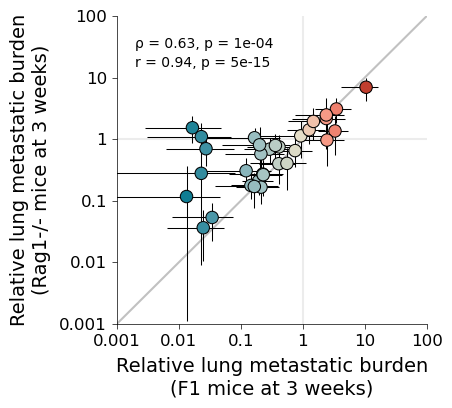

In [8]:
name = 'relative_in_vivo_exp_w_and_wo_immune_system_exp1'
si = 'main'

ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                    clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                    clID__y=clID__in_vivo_exp_avg_wo_immune_system_relative_to_mean, clID__yerr=clID__in_vivo_exp_wo_immune_system_err,
                                    xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks)',
                                    lims=[1e-3, 1e2], ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], labels=['0.001', '0.01', '0.1', '1', '10', '100'])

scatter_points = ax.collections[0] 
positions = scatter_points.get_offsets() 
original_colors = scatter_points.get_facecolor()

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

In [9]:
# calculating immune rejection index
clID__immune_rejection_index_distr = {}
clID__immune_rejection_index_avg = {}
clID__immune_rejection_index_err = {}
for clID in clIDs:
    if clID in ['GATC', 'AGCA']:
        continue
    clID__immune_rejection_index_distr[clID] = clID__in_vivo_exp_wo_immune_system_rel[clID] / clID__in_vivo_exp_rel[clID]

for clID in clIDs:
    if clID in ['GATC', 'AGCA']:
        continue
    y = clID__in_vivo_exp_avg_wo_immune_system_relative_to_mean[clID] / clID__in_vivo_exp_avg_relative_to_mean[clID]
    clID__immune_rejection_index_avg[clID] = y
    
    ci_upper = np.percentile(clID__immune_rejection_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__immune_rejection_index_distr[clID], 2.5)
    clID__immune_rejection_index_err[clID] = [(y - ci_lower), (ci_upper - y)]
       
clIDs_sorted = [y[0] for y in sorted([[x, clID__immune_rejection_index_avg[x]] for x in clIDs if x not in ['GATC', 'AGCA']], key = lambda x: x[-1], reverse=True)]

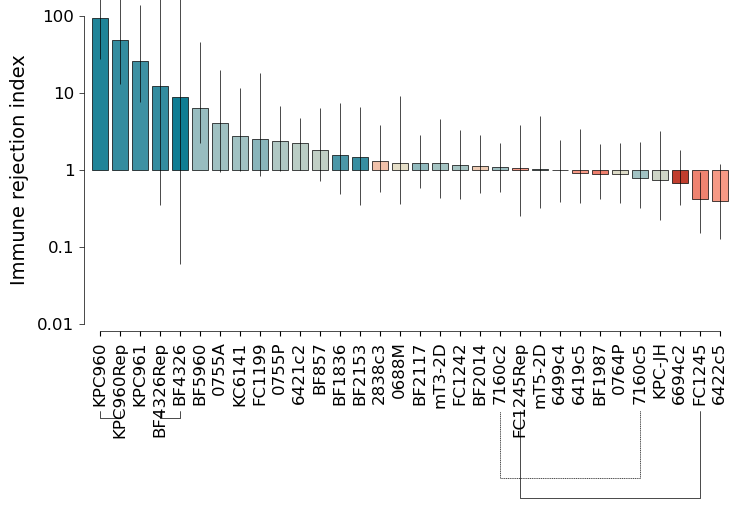

In [12]:
name = 'immune_rejection_index_exp1'
si = 'main'

ax = utils.metric_bar_plot(clIDs_sorted, clID__immune_rejection_index_avg, clID__immune_rejection_index_err, 
                           ytitle='Immune rejection index', 
                           ylims=[1e-2, 1e2], yticks=[1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['0.01', '0.1', '1', '10', '100'])

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


### Seeding plots

In [29]:
# making a list of 2d F1 iv lung samples from exp. one
what = ['1', 3, 'C57B6/129S F1', 'intravenous', 'lung']
samples_2d = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] <= what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [41]:
(
    _,
    _,
    clID__n_tumors_2d_avg_relative_to_mean_original,
    clID__n_tumors_2d_avg_relative_to_mean,
    clID__n_tumors_2d_err, 
    _
) = utils.bootstrap_n_tumors(
    samples_2d,
    path_to_data=path_to_reads,
    read_counts=read_counts_by_cell_line,
    cell_counts=cell_counts_by_cell_line,
    metadata=metadata
)

(
    clID__in_vivo_exp_2d, 
    clID__in_vivo_exp_2d_relative_to_mean, 
    clID__in_vivo_exp_2d_avg_relative_to_mean, 
    clID__in_vivo_exp_2d_err, 
    _
) = utils.bootstrap_relative_burden(
    samples_2d, 
    read_counts=read_counts_by_cell_line,
    cell_counts=cell_counts_by_cell_line,
    metadata=metadata
)


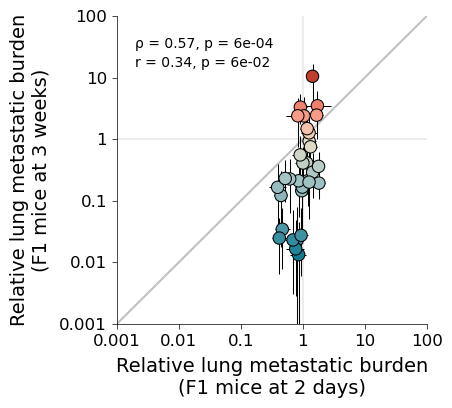

In [42]:
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                    clID__x=clID__in_vivo_exp_2d_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_2d_err,
                                    clID__y=clID__in_vivo_exp_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_err,
                                    xtitle='Relative lung metastatic burden\n(F1 mice at 2 days)', ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)',
                                    lims=[1e-3, 1e2], ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], labels=['0.001', '0.01', '0.1', '1', '10', '100'])

plt.savefig(path_to_save_figs + 'fig3_burden_f1_at_2d_vs_3w.pdf', dpi=300, bbox_inches='tight')  

/Users/alyulina/Research/metastatic-phenotypes/code/utils.py:548: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value


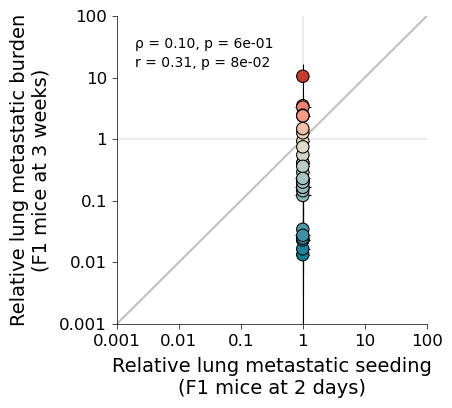

In [43]:
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                    clID__x=clID__n_tumors_2d_avg_relative_to_mean, clID__xerr=clID__n_tumors_2d_err,
                                    clID__y=clID__in_vivo_exp_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_err,
                                    xtitle='Relative lung metastatic seeding\n(F1 mice at 2 days)', ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)',
                                    lims=[1e-3, 1e2], ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], labels=['0.001', '0.01', '0.1', '1', '10', '100'])

plt.savefig(path_to_save_figs + 'fig3_seeding_vs_burden_f1.pdf', dpi=300, bbox_inches='tight')  

/Users/alyulina/Research/metastatic-phenotypes/code/utils.py:548: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value


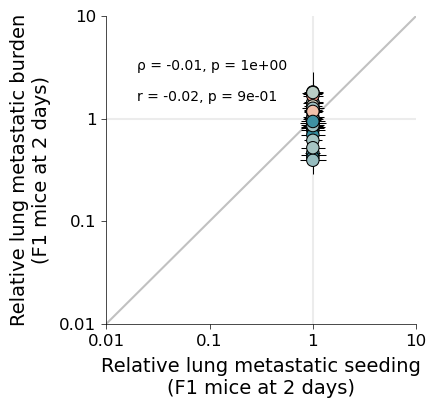

In [44]:
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                    clID__x=clID__n_tumors_2d_avg_relative_to_mean, clID__xerr=clID__n_tumors_2d_err,
                                    clID__y=clID__in_vivo_exp_2d_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2d_err,
                                    xtitle='Relative lung metastatic seeding\n(F1 mice at 2 days)', ytitle='Relative lung metastatic burden\n(F1 mice at 2 days)',
                                    lims=[1e-2, 1e1], ticks=[1e-2, 1e-1, 1e0, 1e1], labels=['0.01', '0.1', '1', '10'])

plt.savefig(path_to_save_figs + 'fig3_seeding_vs_burden_f1_as_2d.pdf', dpi=300, bbox_inches='tight')  

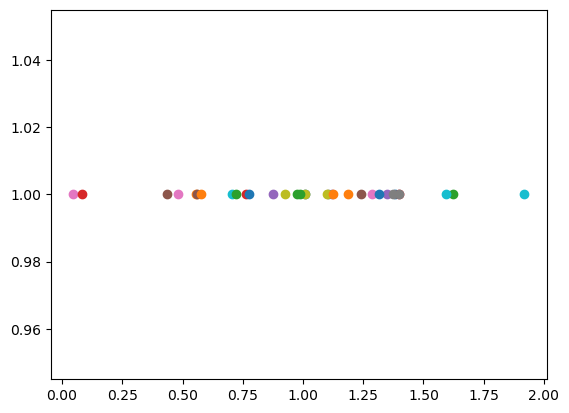

In [47]:
for clID in clIDs[1:]:
    plt.scatter(clID__n_tumors_2d_avg_relative_to_mean_original[clID], clID__n_tumors_2d_avg_relative_to_mean[clID])

In [ ]:
# making a list of 2d Rag1 iv lung samples from exp. one
what = ['1', 3, 'Rag1-/-', 'intravenous', 'lung']
samples_wo_immune_system = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                                 (metadata['time point, d'] <= what[1]) & # be careful here
                                                 (metadata['genotype'] == what[2]) &
                                                 (metadata['injection method'] == what[3]) & 
                                                 (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [ ]:
clID___distr_wo_immune_system, clID___distr_wo_immune_system_relative_to_mean_wo_immune_system, clID__n_tumors_avg_relative_to_mean_wo_immune_system, clID__n_tumors_err_wo_immune_system, clIDs_sorted_wo_immune_system = utils.bootstrap_n_tumors(samples_wo_immune_system, 
                                                                                                                                                                                   path_to_data=path_to_reads, 
                                                                                                                                                                                   read_counts=read_counts_by_cell_line, 
                                                                                                                                                                                   cell_counts=cell_counts_by_cell_line, 
                                                                                                                                                                                   metadata=metadata)


In [ ]:
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                    clID__x=clID__n_tumors_avg_relative_to_mean, clID__xerr=clID__n_tumors_err,
                                    clID__y=clID__n_tumors_avg_relative_to_mean_wo_immune_system, clID__yerr=clID__n_tumors_err_wo_immune_system,
                                    xtitle='Relative lung metastatic seeding\n(F1 mice at 2 days)', ytitle='Relative lung metastatic seeding\n(Rag1-/- mice at 2 days)',
                                    lims=[0.01, 10], ticks=[1e-2, 1e-1, 1e0, 1e1], labels=['0.01', '0.1', '1', '10'])

#plt.savefig(path_to_save_figs + 'fig3_seeding_f1_vs_rag1_recolored.pdf', dpi=300, bbox_inches='tight')  

### Tumor size distributions

In [ ]:
# making a list of 3w F1 iv lung samples from exp. one
what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

print(len(samples))

In [ ]:
clID__percentiles, clID__ci, clID__cum_sum, clID__cum_sum_ci = utils.bootstrap_tumor_size_percentiles(samples,
                                                                                                      path_to_data=path_to_reads,
                                                                                                      percentiles=[50, 60, 70, 80, 90, 99],
                                                                                                      read_counts=read_counts_by_cell_line,
                                                                                                      metadata=metadata)

In [ ]:
_, _, _, _, clIDs_sorted = utils.bootstrap_relative_burden(samples, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)


In [ ]:
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted[:-1]):
    rgb = np.array(clID__color[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(clID__percentiles[clID]))
    for j, p in enumerate(clID__percentiles[clID]):
        plt.scatter(i + j * 0.1, clID__percentiles[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5)
        plt.errorbar(i + j * 0.1, clID__percentiles[clID][j],  [[clID__percentiles[clID][j] - clID__ci[clID][0][j]], [clID__ci[clID][1][j] - clID__percentiles[clID][j]]], color='black', linewidth=0.5, zorder=-1)
    if i % 2 == 0:
        plt.fill_between([i - 0.25, i + j * 0.1 + 0.25], 5e-1, 2e6, color='#e9e9e9', zorder=-2)
        
# for legend:
gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(clID__percentiles[clID]))[::-1]
for j, p in enumerate([50, 60, 70, 80, 90, 99][::-1]):
    plt.scatter(-1, clID__percentiles[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5, label=p)
    
plt.yscale('log')
plt.minorticks_off()

plt.legend(frameon=False, bbox_to_anchor=(0.75, -0.5), ncol=len(gradient), handletextpad=0, columnspacing=0.1)

plt.ylim(5e-1, 2e6)
plt.xlim(-0.25, i + j * 0.1 + 0.25)
plt.yticks(size=12)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='left', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Tumor size, cells', fontsize=14)

#plt.savefig(path_to_save_figs + 'fig3_tumor_size_distr_recolored.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
# want to plot cumulative burden distribution 
sample__clID__barcode__count = utils.convert_barcode_reads_to_cell_counts(samples, 
                                                                          path_to_data=path_to_reads, 
                                                                          read_counts=read_counts_by_cell_line, 
                                                                          metadata=metadata)
clID__tumor_sizes = {}
for i, clID in enumerate(clIDs[1:]):
    if clID not in clID__tumor_sizes:
        clID__tumor_sizes[clID] = []
    for sample in samples:
        clID__tumor_sizes[clID].extend([x for x in sample__clID__barcode__count[sample][clID].values()])


In [ ]:
# pre-injection sample
clID__sample__reads = {}
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index):
    clID__sample__reads[sample] = {}
    file_path = os.path.join(path_to_reads, f"{sample}_clIDs_rBC_cluster_counts.txt")
    
    with open(file_path, 'r') as f:
        for line in f:
            clID_barcode, read_count = line.strip().split('\t')
            clID, barcode = clID_barcode.split('_'); read_count = int(read_count)
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID not in clID__sample__reads[sample]:
                clID__sample__reads[sample][clID] = []
            clID__sample__reads[sample][clID].append(read_count) # adding read counts!


In [ ]:
plt.figure(figsize=(4, 4))

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    sorted_sizes = np.sort(tumor_sizes)
    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    plt.plot(sorted_sizes, cumulative_burden, color=clID__color[clID], label=f"clID {clID}")
    
plt.xscale('log')
#plt.yscale('log')
plt.minorticks_off()
plt.ylim(0, 1)
plt.xlim(1e2, 1e6)

plt.xlabel("Tumor size (cells)")
plt.ylabel("Cumulative contribution to tumor burden")

#plt.savefig(path_to_save_figs + 'fig3_cumulative_burden_by_size_recolored.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(6, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    if clID not in clIDs_sorted[:8]:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 1
        print(clID__label[clID])
                
    sorted_sizes = np.sort(tumor_sizes)
    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    plt.plot(sorted_sizes, cumulative_burden, marker='o', color=c, zorder=z)
    plt.scatter(sorted_sizes[-1], cumulative_burden[-1], color=c, zorder=z, clip_on=False)
    
plt.xscale('log')
plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.ylim(0, 1)
plt.xlim(1e2, 1e6)

plt.xlabel("Tumor size, cells", size=14)
plt.ylabel("Cumulative contribution\nto tumor burden", size=14)

plt.savefig(path_to_save_figs + 'fig3_cumulative_burden_by_size_highlighted_recolored.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(6, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    if clID not in ['AGTC', 'ATCG', 'CACT', 'CAGA', 'CTTC', 'GCAT', 'ACGA', 'AAGG']:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 1 / clIDs_sorted.index(clID)
        print(clID__label[clID])
                
    sorted_sizes = np.sort(tumor_sizes)
    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    plt.plot(sorted_sizes, cumulative_burden, marker='o', color=c, zorder=z)
    plt.scatter(sorted_sizes[-1], cumulative_burden[-1], color=c, zorder=z, clip_on=False)
    
plt.xscale('log')
plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.ylim(0, 1)
plt.xlim(1e2, 1e6)

plt.xlabel("Tumor size, cells", size=14)
plt.ylabel("Cumulative contribution\nto tumor burden", size=14)

#plt.savefig(path_to_save_figs + 'fig3_cumulative_burden_by_size_highlighted_reps.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(3, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    if clID not in clIDs_sorted[:8]:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 2

    sorted_sizes = np.sort(tumor_sizes)[::-1]

    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]

    plt.plot(range(1, len(sorted_sizes) + 1), cumulative_burden, color=c, marker='o', zorder=z, clip_on=False)
    #plt.scatter(1, cumulative_burden[0], color=c, zorder=z)
    #plt.scatter(len(sorted_sizes), 1, color=c, zorder=z, clip_on=False)
        
plt.xscale('log')
plt.yscale('log')
#plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.xlim(0.5e0, 2e3)
plt.ylim(1e-2, 1)

plt.ylabel("Cumulative burden", size=14)
plt.xlabel("Number of tumors\n(from largest downward)", size=14)

#plt.savefig(path_to_save_figs + 'fig3_cumulative_burden_from_the_right_1_recolored.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(3, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    
    sorted_sizes = np.sort(tumor_sizes)[::-1]

    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    
    # ten beiiest tumors contribute less than half burden
    if round(cumulative_burden[10], 1) >= 0.5:
        c = '#e9e9e9'
        z = -1
    else:
        print(round(cumulative_burden[10], 1), clID__label[clID], clID)
        c = clID__color[clID]
        z = 2

    plt.plot(range(1, len(sorted_sizes) + 1), cumulative_burden, color=c, marker='o', zorder=z, clip_on=False)
    #plt.scatter(1, cumulative_burden[0], color=c, zorder=z)
    #plt.scatter(len(sorted_sizes), 1, color=c, zorder=z, clip_on=False)
        
plt.xscale('log')
plt.yscale('log')
#plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.xlim(0.5e0, 2e3)
plt.ylim(1e-2, 1)

plt.ylabel("Cumulative burden", size=14)
plt.xlabel("Number of tumors\n(from largest downward)", size=14)

#plt.savefig(path_to_save_figs + 'fig3_cumulative_burden_from_the_right_2_recolored.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(3, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    
    sorted_sizes = np.sort(tumor_sizes)[::-1]

    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    
    if clID not in ['AGTC', 'ATCG', 'CACT', 'CAGA', 'CTTC', 'GCAT', 'ACGA', 'AAGG']:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 1 / clIDs_sorted.index(clID)
        print(clID__label[clID])

    plt.plot(range(1, len(sorted_sizes) + 1), cumulative_burden, color=c, marker='o', zorder=z, clip_on=False)
    #plt.scatter(1, cumulative_burden[0], color=c, zorder=z)
    #plt.scatter(len(sorted_sizes), 1, color=c, zorder=z, clip_on=False)
        
plt.xscale('log')
plt.yscale('log')
#plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.xlim(0.5e0, 2e3)
plt.ylim(1e-2, 1)

plt.ylabel("Cumulative burden", size=14)
plt.xlabel("Number of tumors\n(from largest downward)", size=14)

#plt.savefig(path_to_save_figs + 'fig3_cumulative_burden_from_the_right_2_reps.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(8, 2))

clID__cum_burden_fraction__sizes = {}
for i, clID in enumerate(clIDs_sorted):
    if clID in ['GATC', 'AGCA']:
        continue
    clID__cum_burden_fraction__sizes[clID] = {}
    for sample in samples:
        tumor_sizes = list(sample__clID__barcode__count[sample][clID].values())
        if len(tumor_sizes) < 2:
            continue
        sorted_sizes = np.sort(tumor_sizes)
        cumulative_burden = np.cumsum(sorted_sizes)
        cumulative_burden /= cumulative_burden[-1]
    
        interpolator = sp.interpolate.interp1d(cumulative_burden, sorted_sizes, kind='linear', fill_value="extrapolate")
        
        b = 0.5
        if b not in clID__cum_burden_fraction__sizes[clID]:
            clID__cum_burden_fraction__sizes[clID][b] = []
        clID__cum_burden_fraction__sizes[clID][b].append(interpolator(b)) # cumulative contribution to tumor burden
        
        plt.scatter(i, interpolator(b), color='none', edgecolor='black', linewidth=0.5)
    
    #means = []
    #for _ in range(10000):
    #    resampled_data = np.random.choice(clID__cum_burden_fraction__sizes[clID][b], size=len(clID__cum_burden_fraction__sizes[clID][b]), replace=True)
    #    means.append(np.mean(resampled_data))
    
    #means = np.array(means)
    #mean = np.mean(means)
    #ci_lower = np.percentile(means, (100 - 95) / 2)
    #ci_upper = np.percentile(means, 100 - (100 - 95) / 2)
    
    #plt.scatter(i, mean, color=clID__color[clID], edgecolor='black', linewidth=0.5)
    #plt.errorbar(i, mean, yerr=[[mean - ci_lower], [ci_upper - mean]], zorder=-1, linewidth=0.5, color='black')

    #if i % 2 == 0:
    #    plt.fill_between([i - 0.5, i + 0.5], 5e-1, 2e6, color='#e9e9e9', zorder=-2)
    
plt.yscale('log')
plt.minorticks_off()
plt.ylim(0.5, 2e6);
plt.xlim(-0.5, i - 1 + 0.5)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='center', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Tumor size, cells', fontsize=14)

#plt.savefig(path_to_save_figs + 'tumor_size_half_burden_not_pooled.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(8, 2))

for i, clID in enumerate(clIDs_sorted):
    if clID in ['GATC', 'AGCA']:
        continue
     
    for sample in samples:
        tumor_sizes = list(sample__clID__barcode__count[sample][clID].values())
        if len(tumor_sizes) < 2:
            continue
        sorted_sizes = np.sort(tumor_sizes)[::-1]
        cumulative_burden = np.cumsum(sorted_sizes)
        cumulative_burden /= cumulative_burden[-1]
        
        y = [j for j in range(1, len(sorted_sizes) + 1) if cumulative_burden[j - 1] <= 0.5]
        if len(y) > 0:
            y = y[-1]
        else:
            y = 0.1
    
        plt.scatter(i + np.random.normal(0, 0.1), y, color='none', edgecolor='black', linewidth=0.5)
    
    
plt.yscale('log')
plt.minorticks_off()
plt.ylim(0.5, 2e2);
plt.xlim(-0.5, i - 1 + 0.5)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='center', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Number of tumors', fontsize=14)

#plt.savefig(path_to_save_figs + 'n_large_tumors_half_burden_not_pooled.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(6, 4))
for clID in clIDs_sorted:
    if clID in ['GATC', 'CCAA', 'TTGG', 'GCTA', 'CACT', 'GCAT', 'CAGA', 'ATCG', 'AGCA']: # excluding spike-in, Panc02, and all cell lines that were rejected / did not seed
        continue 
    tumor_sizes = clID__tumor_sizes[clID]
    bins=np.logspace(0, 7, 10)
    if len(tumor_sizes) > 1:  # KDE needs more than one point
        sns.kdeplot(tumor_sizes, bw_adjust=0.8, gridsize=200, log_scale=True, common_grid=True,
                    label=clID, color=clID__color[clID])
        
        #counts, bin_edges = np.histogram(tumor_sizes, bins=bins)
        #plt.plot(bin_edges[:-1], counts / sum(tumor_sizes), color=clID__color[clID])

plt.xscale('log') 
plt.minorticks_off()
plt.xlim(1e0, 1e6)

plt.xlabel('Tumor size, cells')
plt.ylabel('Tumor burden density')
        

In [ ]:
plt.figure(figsize=(4, 4))

which_clIDs = [i for i in clIDs_sorted if clIDs_sorted.index(i) <=7]

# loop through each clID and plot cumulative burden vs percentile
for clID, tumor_sizes in clID__tumor_sizes.items():
    #if clID not in which_clIDs:
    #    continue
    if clID in ['GATC', 'AGCA']:
        continue
    sorted_sizes = np.sort(tumor_sizes)
    cumulative_burden = np.cumsum(sorted_sizes) # cumulative burden
    cumulative_burden /= cumulative_burden[-1] # normalizing by the total burden

    # compute percentiles (rank of each size in sorted list)
    percentiles = np.linspace(0, 100, len(sorted_sizes))

    plt.plot(percentiles, cumulative_burden, color=clID__color[clID])
    
# now do the same but for pre-injection samples

for sample in clID__sample__reads.keys():
    for clID in clID__sample__reads[sample].keys():
        #if clID not in which_clIDs:
        #    continue
        if clID in ['GATC', 'AGCA']:
            continue
        tumor_sizes = clID__sample__reads[sample][clID]
        sorted_sizes = np.sort(tumor_sizes)
        cumulative_burden = np.cumsum(sorted_sizes).astype(float)  # cumulative burden
        cumulative_burden /= cumulative_burden[-1] # normalizing by the total burden

        # compute percentiles (rank of each size in sorted list)
        percentiles = np.linspace(0, 100, len(sorted_sizes))

        plt.plot(percentiles, cumulative_burden, color='#e9e9e9', zorder=-1)
    
plt.xlim(50, 100)
plt.ylim(0, 1)

plt.xlabel("Tumor size percentile")
plt.ylabel("Cumulative contribution to tumor burden")

#plt.savefig(path_to_save_figs + 'fig3_cumulative_burden_by_rank_recolored.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
n_bootstrap = 1000 

plt.figure(figsize=(4, 4))

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue

    mouse_tumor_sizes = {sample: list(sample__clID__barcode__count[sample][clID].values()) for sample in samples}
    
    sample_size = len(samples)  

    boot_avg_burden = []
    boot_large_tumors = []
    
    for _ in range(n_bootstrap):
        resampled_mice = np.random.choice(samples, size=sample_size, replace=True)  
        
        resampled_sizes = []
        for mouse in resampled_mice:
            resampled_sizes.extend(mouse_tumor_sizes[mouse]) 

        if len(resampled_sizes) == 0:
            continue 

        boot_avg_burden.append(np.sum(np.array([x for x in resampled_sizes if x > 100])) / sample_size)
        boot_large_tumors.append(len([x for x in resampled_sizes if x > 100]) / sample_size)

    x = np.sum([x for x in tumor_sizes if x > 100]) / len(samples)
    y = len([x for x in np.array(tumor_sizes) if x > 100]) / len(samples)
    
    x_err = np.percentile(boot_avg_burden, [2.5, 97.5])
    y_err = np.percentile(boot_large_tumors, [2.5, 97.5])
    
    x_err = [[x - x_err[0]], [x_err[1] - x]]
    y_err = [[y - y_err[0]], [y_err[1] - y]]
    
    if clID in ['ATCG', 'CACT', 'CAGA', 'CGAT', 'GCAT', 'TTGG']:
        c = 'white'
    # plt.text(y, x, clID__label[clID])
    # weirdly good one is BF5960
            
    else:
        c = clID__color[clID]
    # plt.text(y, x, clID__label[clID])
    # bad ones are KPC-JC, BF1836, BF2153

    plt.scatter(y, x, s=60, linewidth=0.5, color=c, edgecolor='black')
    plt.errorbar(y, x, xerr=y_err, yerr=x_err, fmt='none', ecolor='black', zorder=-1, linewidth=0.5)


plt.plot([0, 100], [0 * 1e3, 100 * 1e3], color='#e9e9e9', zorder=-3, linewidth=10) 
plt.plot([0, 100], [0 * 1e4, 100 * 1e4], color='#b9b9b9', zorder=-3, linewidth=10) 
plt.plot([0, 100], [0 * 1e5, 100 * 1e5], color='#777777', zorder=-3, linewidth=10) 

plt.ylabel('Average total tumor burden (cells)', size=12)
plt.xlabel('Average number of tumors > 100 cells', size=12)
plt.xticks(size=12); plt.yticks(size=12)
plt.ylim(5e2, 2e6)
plt.xlim(0.1, 100)

plt.yscale('log'); plt.xscale('log'); plt.minorticks_off()


#plt.savefig(path_to_save_figs + 'fig3_n_tumors_vs_burden_v2_recolored.pdf', dpi=300, bbox_inches='tight')


In [ ]:
for clID in clIDs:
    if clID__label[clID] in ['KPC960', 'KPC961', 'BF4326', 'BF5960']:
        print(clID)

In [ ]:
n_bootstrap = 1000 

plt.figure(figsize=(4, 4))

xs = []; ys = []
for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue

    mouse_tumor_sizes = {sample: list(sample__clID__barcode__count[sample][clID].values()) for sample in samples}
    
    sample_size = len(samples)  

    boot_avg_burden = []
    boot_large_tumors = []
    
    for _ in range(n_bootstrap):
        resampled_mice = np.random.choice(samples, size=sample_size, replace=True)  
        
        resampled_sizes = []
        for mouse in resampled_mice:
            resampled_sizes.extend(mouse_tumor_sizes[mouse]) 

        if len(resampled_sizes) == 0:
            continue 

        boot_avg_burden.append(np.sum(np.array([x for x in resampled_sizes if x > 100])) / sample_size)
        boot_large_tumors.append(len([x for x in resampled_sizes if x > 100]) / sample_size)

    x = np.sum([x for x in tumor_sizes if x > 100]) / len(samples)
    y = len([x for x in np.array(tumor_sizes) if x > 100]) / len(samples)
    
    xs.append(x); ys.append(y)
    
    x_err = np.percentile(boot_avg_burden, [2.5, 97.5])
    y_err = np.percentile(boot_large_tumors, [2.5, 97.5])
    
    x_err = [[x - x_err[0]], [x_err[1] - x]]
    y_err = [[y - y_err[0]], [y_err[1] - y]]

    c = clID__color[clID]

    plt.scatter(y, clID__immune_rejection_index_avg[clID], s=60, linewidth=0.5, color=c, edgecolor='black')
    plt.errorbar(y, clID__immune_rejection_index_avg[clID], 
                 yerr=[[clID__immune_rejection_index_err[clID][0]], [clID__immune_rejection_index_err[clID][1]]], 
                 xerr=y_err,
                 fmt='none', ecolor='black', zorder=-1, linewidth=0.5)
    
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
plt.text(2 * 0.1, 0.3 * 2e3, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
plt.text(2 * 0.1, 0.15 * 2e3, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

plt.ylabel('Immune rejection index', size=12)
plt.xlabel('Average number of tumors > 100 cells', size=12)
plt.xticks(size=12); plt.yticks(size=12)
plt.ylim(0.5e-1, 2e3)
plt.xlim(0.1, 100)

plt.yscale('log'); plt.xscale('log'); plt.minorticks_off()



In [ ]:
n_bootstrap = 1000 

plt.figure(figsize=(4, 4))

xs = []; ys = []
for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue

    mouse_tumor_sizes = {sample: list(sample__clID__barcode__count[sample][clID].values()) for sample in samples}
    
    sample_size = len(samples)  

    boot_avg_burden = []
    boot_large_tumors = []
    
    for _ in range(n_bootstrap):
        resampled_mice = np.random.choice(samples, size=sample_size, replace=True)  
        
        resampled_sizes = []
        for mouse in resampled_mice:
            resampled_sizes.extend(mouse_tumor_sizes[mouse]) 

        if len(resampled_sizes) == 0:
            continue 

        boot_avg_burden.append(np.sum(np.array([x for x in resampled_sizes if x > 100])) / sample_size)
        boot_large_tumors.append(len([x for x in resampled_sizes if x > 100]) / sample_size)

    x = np.sum([x for x in tumor_sizes if x > 100]) / len(samples)
    y = len([x for x in np.array(tumor_sizes) if x > 100]) / len(samples)
    
    xs.append(x); ys.append(y)
    
    x_err = np.percentile(boot_avg_burden, [2.5, 97.5])
    y_err = np.percentile(boot_large_tumors, [2.5, 97.5])
    
    x_err = [[x - x_err[0]], [x_err[1] - x]]
    y_err = [[y - y_err[0]], [y_err[1] - y]]

    c = clID__color[clID]

    plt.scatter(y, clID__immune_rejection_index_avg[clID], s=60, linewidth=0.5, color=c, edgecolor='black')
    plt.errorbar(y, clID__immune_rejection_index_avg[clID], 
                 yerr=[[clID__immune_rejection_index_err[clID][0]], [clID__immune_rejection_index_err[clID][1]]], 
                 xerr=y_err,
                 fmt='none', ecolor='black', zorder=-1, linewidth=0.5)
    
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
plt.text(2 * 0.1, 0.3 * 2e3, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
plt.text(2 * 0.1, 0.15 * 2e3, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

plt.ylabel('Immune rejection index', size=12)
plt.xlabel('Average number of tumors > 100 cells', size=12)
plt.xticks(size=12); plt.yticks(size=12)
plt.ylim(0.5e-1, 2e3)
plt.xlim(0.1, 100)

plt.yscale('log'); plt.xscale('log'); plt.minorticks_off()



### Supplementary figure: barcode presence/absence as a function of initial frequency

In [ ]:
# slightly different from above as we are keeping the barcodes now
clID__sample__reads = {}
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index): # pre-injection
    clID__sample__reads[sample] = {}
    file_path = os.path.join(path_to_reads, f"{sample}_clIDs_rBC_cluster_counts.txt")
    
    with open(file_path, 'r') as f:
        for line in f:
            clID_barcode, read_count = line.strip().split('\t')
            clID, barcode = clID_barcode.split('_'); read_count = int(read_count)
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID not in clID__sample__reads[sample]:
                clID__sample__reads[sample][clID] = {}
            clID__sample__reads[sample][clID][barcode] = read_count # adding read counts!
            
sample__clID__barcode__count = utils.convert_barcode_reads_to_cell_counts(samples, 
                                                                          path_to_data=path_to_reads, 
                                                                          read_counts=read_counts_by_cell_line, 
                                                                          metadata=metadata)
clID__sample__freqs = {}
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index):
    n_total = sum([sum(clID__sample__reads[sample][i].values()) for i in clIDs if i not in ['GATC', 'AGCA']])
    
    clID__sample__freqs[sample] = {}
    for clID, barcodes in clID__sample__reads[sample].items():
        if clID in ['GATC', 'AGCA']:
            continue 
        clID__sample__freqs[sample][clID] = {} 

        for barcode, count in barcodes.items():
            clID__sample__freqs[sample][clID][barcode] = count / n_total 

clID__barcodes = {}
for i, clID in enumerate(clIDs[1:]):
    if clID not in clID__barcodes:
        clID__barcodes[clID] = []
    for sample in samples:
        clID__barcodes[clID].extend([x for x in sample__clID__barcode__count[sample][clID].keys()])
        

In [ ]:
# now the same but for unclustered reads
clID__sample__reads_not_clustered = {}
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index): # pre-injection
    clID__sample__reads_not_clustered[sample] = {}
    file_path = os.path.join(path_to_reads_not_clustered, f"{sample}_clID_rBC_extracted.txt")
    
    with open(file_path, 'r') as f:
        for line in f:
            _, clID, barcode = line.strip().split('\t')
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID not in clID__sample__reads_not_clustered[sample]:
                clID__sample__reads_not_clustered[sample][clID] = {}
            if barcode not in clID__sample__reads_not_clustered[sample][clID]:
                clID__sample__reads_not_clustered[sample][clID][barcode] = 1
            else:
                clID__sample__reads_not_clustered[sample][clID][barcode] += 1 # adding read counts!
            
clID__sample__freqs_not_clustered = {}
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index):
    n_total = sum([sum(clID__sample__reads_not_clustered[sample][i].values()) for i in clIDs if i not in ['GATC', 'AGCA']])
    
    clID__sample__freqs_not_clustered[sample] = {}
    for clID, barcodes in clID__sample__reads_not_clustered[sample].items():
        if clID in ['GATC', 'AGCA']:
            continue 
        clID__sample__freqs_not_clustered[sample][clID] = {} 

        for barcode, count in barcodes.items():
            clID__sample__freqs_not_clustered[sample][clID][barcode] = count / n_total 
            
sample__clID__barcode__count_not_clustered = {}
for sample in list(itertools.chain(*[x.split(':') for x in samples])): # in vivo
    sample__clID__barcode__count_not_clustered[sample] = {}
    file_path = os.path.join(path_to_reads_not_clustered, f"{sample}_clID_rBC_extracted.txt")
    
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue 
        sample__clID__barcode__count_not_clustered[sample][clID] = {}
    
    with open(file_path, 'r') as f:
        for line in f:
            _, clID, barcode = line.strip().split('\t')
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID in ['GATC', 'AGCA']:
                continue 
            if barcode not in sample__clID__barcode__count_not_clustered[sample][clID]:
                sample__clID__barcode__count_not_clustered[sample][clID][barcode] = 1
            else:
                sample__clID__barcode__count_not_clustered[sample][clID][barcode] += 1 # adding read counts!

clID__barcodes_not_clustered = {}
for i, clID in enumerate(clIDs[1:]):
    if clID in ['GATC', 'AGCA']:
            continue 
    if clID not in clID__barcodes_not_clustered:
        clID__barcodes_not_clustered[clID] = []
    for sample in list(itertools.chain(*[x.split(':') for x in samples])):
        clID__barcodes_not_clustered[clID].extend([x for x in sample__clID__barcode__count_not_clustered[sample][clID].keys()])
        

In [ ]:
plt.figure(figsize=(4, 4))
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index): # pre-injection
    if sample != 'SK1_61':
        continue
    
    # clustered
    f_presence = []
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue
        for barcode, f in clID__sample__freqs[sample][clID].items():
            f_presence.append([f, 1 if barcode in clID__barcodes[clID] else 0])

    f_presence = np.array(f_presence)
    frequencies = f_presence[:, 0]  
    presences = f_presence[:, 1]    
    
    n_bins = 10
    bins = np.logspace(np.log10(min(frequencies)), np.log10(max(frequencies)), n_bins + 1)
    bin_indices = np.digitize(frequencies, bins) - 1  

    avg_presence = []
    bin_centers = []

    for i in range(n_bins):
        bin_mask = bin_indices == i  # get indices of frequencies in this bin
        bin_count = np.sum(bin_mask)  # total number of data points in the bin

        avg_presence.append(np.mean(presences[bin_mask]))  # compute fraction present
        bin_centers.append(np.sqrt(bins[i] * bins[i+1]))  # use geometric mean as bin center

    plt.plot(bin_centers, avg_presence, marker='o', color='black')
    
    # not clustered
    f_presence = []
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue
        for barcode, f in clID__sample__freqs_not_clustered[sample][clID].items():
            f_presence.append([f, 1 if barcode in clID__barcodes_not_clustered[clID] else 0])

    f_presence = np.array(f_presence)
    frequencies = f_presence[:, 0]  
    presences = f_presence[:, 1]    
    
    n_bins = 10
    bins = np.logspace(np.log10(min(frequencies)), np.log10(max(frequencies)), n_bins + 1)
    bin_indices = np.digitize(frequencies, bins) - 1  

    avg_presence = []
    bin_centers = []

    for i in range(n_bins):
        bin_mask = bin_indices == i  # get indices of frequencies in this bin
        bin_count = np.sum(bin_mask)  # total number of data points in the bin

        avg_presence.append(np.mean(presences[bin_mask]))  # compute fraction present
        bin_centers.append(np.sqrt(bins[i] * bins[i+1]))  # use geometric mean as bin center

    plt.plot(bin_centers, avg_presence, marker='o', color='#b9b9b9')
    
    
# for legend:
plt.plot([1, 1], [10, 10], marker='o', color='#b9b9b9', label='Before clustering')
plt.plot([1, 1], [10, 10], marker='o', color='black', label='After clustering')
plt.legend(frameon=False, loc='upper left')

plt.xscale('log')
plt.yscale('log')
plt.minorticks_off()
plt.ylim(1e-2, 1)
plt.xlim(2e-6, 5e-3)
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel('Initial barcode frequency', size=12)
plt.ylabel('Average fraction present\nin n=20 3 week BL6/129 F1\nlung samples', size=12)
    
#plt.savefig(path_to_save_figs + 'fig3_fraction_present_vs_freq.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
# now doing the opposite

clID__sample__reads = {} # pre-injection
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index): # pre-injection
    clID__sample__reads[sample] = {}
    file_path = os.path.join(path_to_reads, f"{sample}_clIDs_rBC_cluster_counts.txt")
    
    with open(file_path, 'r') as f:
        for line in f:
            clID_barcode, read_count = line.strip().split('\t')
            if float(read_count) < 1:
                continue
            clID, barcode = clID_barcode.split('_'); read_count = int(read_count)
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID not in clID__sample__reads[sample]:
                clID__sample__reads[sample][clID] = {}
            clID__sample__reads[sample][clID][barcode] = read_count # adding read counts!
            
sample__clID__barcode__count = utils.convert_barcode_reads_to_cell_counts(samples, 
                                                                          path_to_data=path_to_reads, 
                                                                          read_counts=read_counts_by_cell_line, 
                                                                          metadata=metadata)
clID__sizes = {}
for sample in samples:    
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue 
        if clID not in clID__sizes:
            clID__sizes[clID] = {}
        for barcode, count in sample__clID__barcode__count[sample][clID].items():
            clID__sizes[clID][barcode] = count 


In [ ]:
# now the same but for unclustered reads

clID__sample___not_clustered = {} # pre-injection
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index): # pre-injection
    clID__sample__reads_not_clustered[sample] = {}
    file_path = os.path.join(path_to_reads_not_clustered, f"{sample}_clID_rBC_extracted.txt")
    
    with open(file_path, 'r') as f:
        for line in f:
            _, clID, barcode = line.strip().split('\t')
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID not in clID__sample__reads_not_clustered[sample]:
                clID__sample__reads_not_clustered[sample][clID] = {}
            if barcode not in clID__sample__reads_not_clustered[sample][clID]:
                clID__sample__reads_not_clustered[sample][clID][barcode] = 1
            else:
                clID__sample__reads_not_clustered[sample][clID][barcode] += 1 # adding read counts
            
sample__clID__barcode__count_not_clustered = {}
for sample in list(itertools.chain(*[x.split(':') for x in samples])): # in vivo
    sample__clID__barcode__count_not_clustered[sample] = {}
    file_path = os.path.join(path_to_reads_not_clustered, f"{sample}_clID_rBC_extracted.txt")
    
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue 
        sample__clID__barcode__count_not_clustered[sample][clID] = {}
    
    with open(file_path, 'r') as f:
        for line in f:
            _, clID, barcode = line.strip().split('\t')
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID in ['GATC', 'AGCA']:
                continue 
            if barcode not in sample__clID__barcode__count_not_clustered[sample][clID]:
                sample__clID__barcode__count_not_clustered[sample][clID][barcode] = 1
            else:
                sample__clID__barcode__count_not_clustered[sample][clID][barcode] += 1 # adding read counts!
                
                
clID__sizes_not_clustered = {}
for sample in list(itertools.chain(*[x.split(':') for x in samples])):
    for i, clID in enumerate(clIDs[1:]):
        if clID in ['GATC', 'AGCA']:
            continue 
        if clID not in clID__sizes_not_clustered:
            clID__sizes_not_clustered[clID] = {}

        for barcode, count in sample__clID__barcode__count_not_clustered[sample][clID].items():
            clID__sizes_not_clustered[clID][barcode] = count 
        


In [ ]:
plt.figure(figsize=(4, 4))
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index): # pre-injection
    if sample != 'SK1_61':
        continue
    
    # clustered
    s_presence = []
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue
        for barcode, s in clID__sizes[clID].items():
            s_presence.append([s, 1 if barcode in clID__sample__reads[sample][clID] else 0])

    s_presence = np.array(s_presence)
    sizes = s_presence[:, 0]  
    presences = s_presence[:, 1]    
    
    n_bins = 10
    bins = np.logspace(np.log10(min(sizes)), np.log10(max(sizes)), n_bins + 1)
    bin_indices = np.digitize(sizes, bins) - 1  

    avg_presence = []
    bin_centers = []

    for i in range(n_bins):
        bin_mask = bin_indices == i  # get indices of frequencies in this bin
        bin_count = np.sum(bin_mask)  # total number of data points in the bin

        avg_presence.append(np.mean(presences[bin_mask]))  # compute fraction present
        bin_centers.append(np.sqrt(bins[i] * bins[i+1]))  # use geometric mean as bin center

    plt.plot(bin_centers, avg_presence, marker='o', color='black')   
    
    # not clustered
    s_presence = []
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue
        for barcode, s in clID__sizes_not_clustered[clID].items():
            s_presence.append([s, 1 if barcode in clID__sample__reads_not_clustered[sample][clID] else 0])

    s_presence = np.array(s_presence)
    sizes = s_presence[:, 0]  
    presences = s_presence[:, 1]    
    
    n_bins = 10
    bins = np.logspace(np.log10(min(sizes)), np.log10(max(sizes)), n_bins + 1)
    bin_indices = np.digitize(sizes, bins) - 1  

    avg_presence = []
    bin_centers = []

    for i in range(n_bins):
        bin_mask = bin_indices == i  # get indices of frequencies in this bin
        bin_count = np.sum(bin_mask)  # total number of data points in the bin

        avg_presence.append(np.mean(presences[bin_mask]))  # compute fraction present
        bin_centers.append(np.sqrt(bins[i] * bins[i+1]))  # use geometric mean as bin center

    plt.plot(bin_centers, avg_presence, marker='o', color='#b9b9b9')   
    
# for legend:
plt.plot([1, 1], [10, 10], marker='o', color='#b9b9b9', label='Before clustering')
plt.plot([1, 1], [10, 10], marker='o', color='black', label='After clustering')
plt.legend(frameon=False, loc='lower left')

plt.xscale('log')
plt.yscale('log')
plt.minorticks_off()
plt.ylim(1e-2, 1)
plt.xlim(1e0, 1e6)
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel('Tumor size, cells', size=12)
plt.ylabel('Average fraction present\nin pre-injection sample', size=12)
    
#plt.savefig(path_to_save_figs + 'fig3_fraction_present_vs_size.pdf', dpi=300, bbox_inches='tight')  

### Supplementary figure: Levy, Blundell plots

In [ ]:
sample = 'SK1_61'
ns = [1e0, 3e0, 1e1, 3e1]
dn = 0.34

# making a list of 3w F1 iv lung samples from exp. one
what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

sample__clID__barcode__count = utils.convert_barcode_reads_to_cell_counts(samples, 
                                                                          path_to_data=path_to_reads, 
                                                                          read_counts=read_counts_by_cell_line, 
                                                                          metadata=metadata)

clID__n__tumor_sizes = {}
for clID in clIDs:
    if clID in ['GATC', 'AGCA']:
            continue 
            
    clID__n__tumor_sizes[clID] = {}
    for n in ns:
        clID__n__tumor_sizes[clID][n] = []
        for bc, n_reads in clID__sample__reads[sample][clID].items():
            if n - n * dn <= n_reads <= n + n * dn:
                for s in samples:
                    clID__n__tumor_sizes[clID][n].append(sample__clID__barcode__count[s][clID].get(bc, 0))
                

In [ ]:
plt.figure(figsize=(18, 4))
grid = gridspec.GridSpec(ncols=4, nrows=1,
                         width_ratios=[1, 1, 1, 1], wspace=0.1,
                         height_ratios=[1], hspace=0.5)

clIDs_filtered = set()
c = 0
for i in range(len(ns)):
    plt.subplot(grid[0, c])
    
    n = ns[i]
    
    d = 0
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue 
        
        else:
            sizes = clID__n__tumor_sizes[clID][n]
            bins = np.logspace(0, 8, num=19)
            counts, bin_edges = np.histogram(sizes, bins=bins)
            #if len([x for x in sizes if x > 1e2]) >= 20:
            plt.plot(bin_edges[:-1], counts, color=clID__color[clID], linewidth=2, label=clID__label[clID])
            clIDs_filtered.add(clID)
            #d += 1
            #else:
            #plt.plot(bin_edges[:-1], counts, color='#e9e9e9', linewidth=2, zorder=-1e3)

    
    plt.plot([1e2, 1e2], [1, 1e3], color='#b9b9b9', linewidth=6, zorder=-1e3, alpha=0.3)
    plt.xscale('log'); plt.yscale('log'); plt.minorticks_off()
    plt.xticks([1e0, 1e2, 1e4, 1e6], size=12); 
    plt.xlim(1, 1e6); plt.ylim(1, 1e3)
    
    plt.xlabel('Tumor size, cells', size=14, labelpad=8)
    #plt.legend(frameon=False, ncol=int(d / 8) + 1, alignment='left')

    if c == 0:
        plt.ylabel('Number of tumors', size=14, labelpad=8)
        plt.title(f'{n:.0f} read in pre-injection sample')
        plt.yticks([1e0, 1e1, 1e2, 1e3], size=12)
    else:
        plt.title(f'{n:.0f}±{n*dn:.0f} reads in pre-injection sample')
        plt.yticks([], [])
        
    c += 1
    
#plt.savefig(path_to_save_figs + 'fig3_si_levy_blundell_v2.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
# now in pre-injection sample:

clID__n__n_reads = {}
for clID in clIDs:
    if clID in ['GATC', 'AGCA']:
            continue 
            
    clID__n__n_reads[clID] = {}
    for n in ns:
        clID__n__n_reads[clID][n] = []
        for bc, n_reads in clID__sample__reads[sample][clID].items():
            if n - n * dn <= n_reads <= n + n * dn:
                clID__n__n_reads[clID][n].append(clID__sample__reads['SK1_62'][clID].get(bc, 0))
                


In [ ]:
plt.figure(figsize=(18, 4))
grid = gridspec.GridSpec(ncols=4, nrows=1,
                         width_ratios=[1, 1, 1, 1], wspace=0.1,
                         height_ratios=[1], hspace=0.5)

clIDs_filtered = set()
c = 0
for i in range(len(ns)):
    plt.subplot(grid[0, c])
    
    n = ns[i]
    
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue 
        
        else:
            sizes = clID__n__n_reads[clID][n]
            bins = np.logspace(0, 3, num=12)
            counts, bin_edges = np.histogram(sizes, bins=bins)
            
            plt.plot(bin_edges[:-1], counts, color=clID__color[clID], linewidth=2, zorder=-1e3)

    
    plt.plot([1e2, 1e2], [1, 1e3], color='#b9b9b9', linewidth=6, zorder=-1e3, alpha=0.3)
    plt.xscale('log'); plt.yscale('log'); plt.minorticks_off()
    plt.xticks([1e0, 1e2, 1e4, 1e6], size=12); 
    plt.xlim(1, 1e6); plt.ylim(1, 1e3)
    
    plt.xlabel('Number of reads', size=14, labelpad=8)

    if c == 0:
        plt.ylabel('Number of barcodes', size=14, labelpad=8)
        plt.title(f'{n:.0f} read in pre-injection sample')
        plt.yticks([1e0, 1e1, 1e2, 1e3], size=12)
    else:
        plt.title(f'{n:.0f}±{n*dn:.0f} reads in pre-injection sample')
        plt.yticks([], [])
        
    c += 1
    
#plt.savefig(path_to_save_figs + 'fig3_si_levy_blundell_reps.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
# for each pre-injection sample, given that there were 2000000 injected, 
# what was the number of barcodes that made it?
# need f * N > 3

plt.figure(figsize=(8, 3))
plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)

N = 200000

for i, clID in enumerate(clIDs_sorted):
    if clID in ['GATC', 'AGCA']:
        continue 
        
    else:
        sizes = list(clID__sample__reads['SK1_62'][clID].values())
        freqs = np.array(sizes) / sum(sizes)
        n = len([x for x in freqs if x * N >= 3])
        #print(n)
        
        plt.scatter(i, n, color=clID__color[clID], edgecolor='black', linewidth=0.5, clip_on=False)
        plt.plot([i, i], [0, n], color='black', linewidth=0.5, zorder=0)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='center', size=12);

plt.xlim(-1, 32)
plt.ylim(0, 15000)

plt.yticks([0, 2500, 5000, 7500, 10000, 12500, 15000]);
plt.gca().xaxis.set_tick_params(width=0)

clID__weight = {}
for clID in clIDs:
    if clID__label[clID] in ['6694c2', '6419c5', 'BF1987', '0688M', 'FC1245', 'FC1245', 'KPC-JH', '0755A', '2838c3']:
        clID__weight[clID] = 'bold'
    else:
        clID__weight[clID] = 'normal'
        
for label, clID in zip(plt.gca().get_xticklabels(), clIDs_sorted):
    label.set_fontproperties(matplotlib.font_manager.FontProperties(weight=clID__weight[clID]))  


plt.annotate('', xy=(2, -4800), xycoords='data', xytext=(4, -4800), textcoords='data',
            arrowprops=dict(arrowstyle='-', linewidth=w, color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.3'), 
            annotation_clip=False);

plt.annotate('', xy=(29, -4200), xycoords='data', xytext=(31, -4200), textcoords='data',
            arrowprops=dict(arrowstyle='-', linewidth=w, color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

plt.annotate('', xy=(28, -4500), xycoords='data', xytext=(30, -4500), textcoords='data',
            arrowprops=dict(arrowstyle='-', linewidth=w, color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.2'), 
            annotation_clip=False);

plt.annotate('', xy=(17, -4500), xycoords='data', xytext=(20, -4500), textcoords='data',
            arrowprops=dict(arrowstyle='-', linewidth=w, linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.2'), 
            annotation_clip=False);

#plt.savefig(path_to_save_figs + 'fig3_si_n_barcodes_transplanted.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
clID__label

### Supplementary figures: tumor size percentiles vs relative in vivo expansion

In [ ]:
percentiles = [50, 60, 70, 80, 90, 99]

plt.figure(figsize=(18, 4))
grid = gridspec.GridSpec(ncols=4, nrows=1,
                         width_ratios=[1, 1, 1, 1], wspace=0.2,
                         height_ratios=[1], hspace=0.5)

c = 0
for i in range(len(percentiles)):
    
    if percentiles[i] not in [50, 80, 90, 99]:
        continue
        
    plt.subplot(grid[0, c])
    
    xs = []; ys = []
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue

        x = clID__in_vivo_exp_avg_relative_to_mean[clID]
        y = clID__percentiles[clID][i]

        plt.scatter(x, y, color=clID__color[clID], s=80, edgecolor='black', linewidth=0.75, alpha=1, zorder=1)
        plt.errorbar(x, y, 
                     xerr=[[clID__in_vivo_exp_err[clID][0]], [clID__in_vivo_exp_err[clID][1]]], 
                     yerr=[[y - clID__ci[clID][0][i]], [clID__ci[clID][1][i] - y]], 
                     color='black', linewidth=0.75, ls='none', zorder=-2)
        #plt.text(x, y, clID__label[clID])
        
        xs.append(x)
        ys.append(y)
    
    spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
    pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
    plt.text(2e-3, 2e6, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
    plt.text(2e-3, 1e6, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)
    
    plt.yscale('log')
    plt.xscale('log')
    plt.minorticks_off()
    
    plt.xticks([1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], 
               ['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$10^0$', '$10^1$', '$10^2$'],
               size=14)
    plt.xlabel('Relative lung metastatic burden', fontsize=14, labelpad=8)
        
    if i == 0:
        plt.yticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7], 
                   ['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$', '$10^6$', '$10^7$'],
                   size=14)
        plt.ylabel('Tumor size, cells', fontsize=14, labelpad=8)
    else:
        plt.yticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7], []) 
        
    plt.title(str(percentiles[i]) + 'th percentile', size=14)

    plt.ylim(1e0, 1e7)
    plt.xlim(1e-3, 1e2)
    
    c += 1

#plt.savefig(path_to_save_figs + 'fig3_si_percentile_vs_burden.pdf', dpi=300, bbox_inches='tight')  